In [ ]:
import requests
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import gpytorch
url = "http://127.0.0.1:80"
testcase = 'bestest_air'
print("done")

done


In [ ]:
device = torch.device('cpu')
print("Using:", device)


data = pd.read_csv('converted_data.csv')
room_temp = data['room_temp'].values / 30.0
temp_sup  = data['temp_sup'].values  / 40.0
air       = data['airflow'].values   

pos_tem = room_temp[1:]
cur_tem = room_temp[:-1]
tem_sup = temp_sup[:-1]
airflow = air[:-1]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def data_split(Ns, Ne, x1, x2, x3, y):
    return (to_tensor(x1[Ns:Ne]).view(-1,1),
            to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1),
            to_tensor(y[Ns:Ne]).view(-1,1))

Ns_tr, Ne_tr = 0, 10     
Ns_t, Ne_t = 200, 250 

cur_tem_tr, tem_sup_tr, airflow_tr, pos_tem_tr = data_split(Ns_tr, Ne_tr, cur_tem, tem_sup, airflow, pos_tem)
cur_tem_t, tem_sup_t, airflow_t, pos_tem_t = data_split(Ns_t, Ne_t, cur_tem, tem_sup, airflow, pos_tem)

X_tr = torch.cat((cur_tem_tr, tem_sup_tr, airflow_tr), dim=1)
y_tr = pos_tem_tr.squeeze(-1)

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=train_x.size(-1))
        )
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
model = ExactGPModel(X_tr, y_tr, likelihood).to(device)
state_dict = torch.load('model_GP.pth')
model.load_state_dict(state_dict)
model.eval(); likelihood.eval()
model.double(); likelihood.double()
Xtr_np = X_tr.detach().cpu().numpy()
ytr_np = y_tr.detach().cpu().numpy().reshape(-1,1)
ell  = model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().reshape(-1)
sf2  = model.covar_module.outputscale.detach().cpu().item()
sn2  = model.likelihood.noise.detach().cpu().item()
jitter = 1e-6

def mean_on(model, X_np):
    """Return m(X) as (N,1) numpy using the GPyTorch mean_module."""
    X_t = torch.tensor(X_np, dtype=torch.double)
    m = model.mean_module(X_t).detach().cpu().numpy().reshape(-1,1)
    return m

def mean_at(model, x_np):
    """Return m(x*) as scalar numpy."""
    x_t = torch.tensor(x_np.reshape(1,-1), dtype=torch.double)
    m = model.mean_module(x_t).detach().cpu().numpy().item()
    return m

mX_np = mean_on(model, Xtr_np)
y_cen = ytr_np - mX_np

def rbf_kernel(X1, X2, ell, sf2):
    X1s = X1 / ell
    X2s = X2 / ell
    d2 = np.sum(X1s**2, axis=1)[:,None] + np.sum(X2s**2, axis=1)[None,:] - 2.0*(X1s @ X2s.T)
    return sf2 * np.exp(-0.5*d2)

K  = rbf_kernel(Xtr_np, Xtr_np, ell, sf2)
Ky = K + (sn2 + jitter) * np.eye(Xtr_np.shape[0])
alpha = np.linalg.solve(Ky, y_cen)

Xtr_dm   = ca.DM(Xtr_np)
alpha_dm = ca.DM(alpha)
ell_dm   = ca.DM(ell).T
sf2_dm   = float(sf2)
Ntr      = Xtr_dm.size1()

def casadi_gp_mean(x):
    diff = ca.repmat(x.T, Ntr, 1) - Xtr_dm
    diff_s = diff / ca.repmat(ell_dm, Ntr, 1)
    r2 = ca.sum2(diff_s**2)
    kx = sf2_dm * ca.exp(-0.5 * r2)
    mu_centered = ca.mtimes(kx.T, alpha_dm)
    return mu_centered

x_sym = ca.SX.sym('x', 1)
u_sym = ca.SX.sym('u', 2)
xu = ca.vertcat(x_sym, u_sym)
f_gp = ca.Function('f_gp', [xu], [casadi_gp_mean(xu)])

Using: cpu


In [21]:
def mpc_implement(x0, x_ref, f_gp, horizon=10):
    x0 = x0/30.0
    x_ref = x_ref/30.0
    nx, nu = 1, 2
    Q = ca.DM([[2000.0]])
    R = ca.DM([[0.6, 0.0],
               [0.0, 0.15]])
    opti = ca.Opti()
    X = opti.variable(nx, horizon + 1)
    U = opti.variable(nu, horizon)
    u_min = ca.DM([.3, 0.0])
    u_max = ca.DM([1.0, 1.0])
    opti.subject_to(X[:, 0] == x0)

    cost = 0
    for k in range(horizon):
        x_k = X[:, k]
        u_k = U[:, k]
        x_err = x_k - x_ref

        cost += ca.mtimes([x_err.T, Q, x_err]) + ca.mtimes([u_k.T, R, u_k])
        z_k = ca.vertcat(x_k, u_k)
        x_next = f_gp(z_k)
        opti.subject_to(X[:, k+1] == x_next)
        opti.subject_to(u_min <= u_k) 
        opti.subject_to(u_k <= u_max) 
        opti.subject_to(X[:, 0] == x0)  
    xT_err = X[:, -1] - x_ref
    cost += ca.mtimes([xT_err.T, Q, xT_err])
    opti.minimize(cost)
    solver_opts = {'ipopt': {'print_level': 0, 'max_iter': 1000}, 'print_time': 0}
    opti.solver('ipopt', solver_opts)
    sol = opti.solve()
    u0 = sol.value(U[:, 0]).flatten()
    u = {'fcu_oveTSup_u': u0[0]*40 + 273.15 ,
         'fcu_oveTSup_activate': 1, 
         'fcu_oveFan_u': u0[1],
         'fcu_oveFan_activate': 1}
    return u

In [22]:
y = requests.put('{0}/initialize/{1}'.format(url, testid), 
                 json={'start_time':   31*24*3600,
                       'warmup_period': 7*24*3600}).json()['payload']
print(y.keys())
print(y['zon_reaTRooAir_y']-273.15)
print(y['time']/24/3600)
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'peak_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':300})
start_time_days = y['time']/24/3600

dict_keys(['time', 'fcu_reaFloSup_y', 'fcu_reaPCoo_y', 'fcu_reaPFan_y', 'fcu_reaPHea_y', 'zon_reaCO2RooAir_y', 'zon_reaPLig_y', 'zon_reaPPlu_y', 'zon_reaTRooAir_y', 'zon_weaSta_reaWeaCeiHei_y', 'zon_weaSta_reaWeaCloTim_y', 'zon_weaSta_reaWeaHDifHor_y', 'zon_weaSta_reaWeaHDirNor_y', 'zon_weaSta_reaWeaHGloHor_y', 'zon_weaSta_reaWeaHHorIR_y', 'zon_weaSta_reaWeaLat_y', 'zon_weaSta_reaWeaLon_y', 'zon_weaSta_reaWeaNOpa_y', 'zon_weaSta_reaWeaNTot_y', 'zon_weaSta_reaWeaPAtm_y', 'zon_weaSta_reaWeaRelHum_y', 'zon_weaSta_reaWeaSolAlt_y', 'zon_weaSta_reaWeaSolDec_y', 'zon_weaSta_reaWeaSolHouAng_y', 'zon_weaSta_reaWeaSolTim_y', 'zon_weaSta_reaWeaSolZen_y', 'zon_weaSta_reaWeaTBlaSky_y', 'zon_weaSta_reaWeaTDewPoi_y', 'zon_weaSta_reaWeaTDryBul_y', 'zon_weaSta_reaWeaTWetBul_y', 'zon_weaSta_reaWeaWinDir_y', 'zon_weaSta_reaWeaWinSpe_y', 'con_oveTSetCoo_activate', 'con_oveTSetCoo_u', 'con_oveTSetHea_activate', 'con_oveTSetHea_u', 'fcu_oveFan_activate', 'fcu_oveFan_u', 'fcu_oveTSup_activate', 'fcu_oveTSup_

In [23]:
last_change_day = start_time_days
x_ref_c = 28
x_ref = x_ref_c

while y:
    clear_output(wait=True)
    print('-------------------------------------------------------------------')
    print('Operative temperature [degC]  = {:.2f}'.format(y['zon_reaTRooAir_y']-273.15))
    simulation_time_days = y['time']/3600/24
    print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))
    x0 = y['zon_reaTRooAir_y']-273.15
    u = mpc_implement(x0=x0, x_ref=x_ref, f_gp=f_gp, horizon=3)
    
    print('-------------------------------------------------------------------')
    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']    
    if (simulation_time_days - start_time_days) > 2:
        break

-------------------------------------------------------------------
Operative temperature [degC]  = 28.06
Simulation time [elapsed days] = 2.00
-------------------------------------------------------------------


   zon_reaTRooAir_y  fcu_oveFan_u  fcu_oveTSup_u      time
0        295.053908           0.0     294.150000  28857600
1        296.380189           1.0     313.149999  28857630
2        297.907983           1.0     313.149999  28857660
3        299.183142           1.0     313.149999  28857690
4        300.245646           1.0     313.149999  28857720


<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
C:\Users\namng\AppData\Local\Temp\ipykernel_15640\3526521112.py:18: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set_ylabel('Operative\ntemperature\n($^\circ$C)')
C:\Users\namng\AppData\Local\Temp\ipykernel_15640\3526521112.py:30: SyntaxWarning: invalid escape sequence '\c'
  axs[2].set_ylabel('Ambient\ntemperature\n($^\circ$C)')
C:\Users\namng\AppData\Local\Temp\ipykernel_15640\3526521112.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axt.legend(loc='upper right')


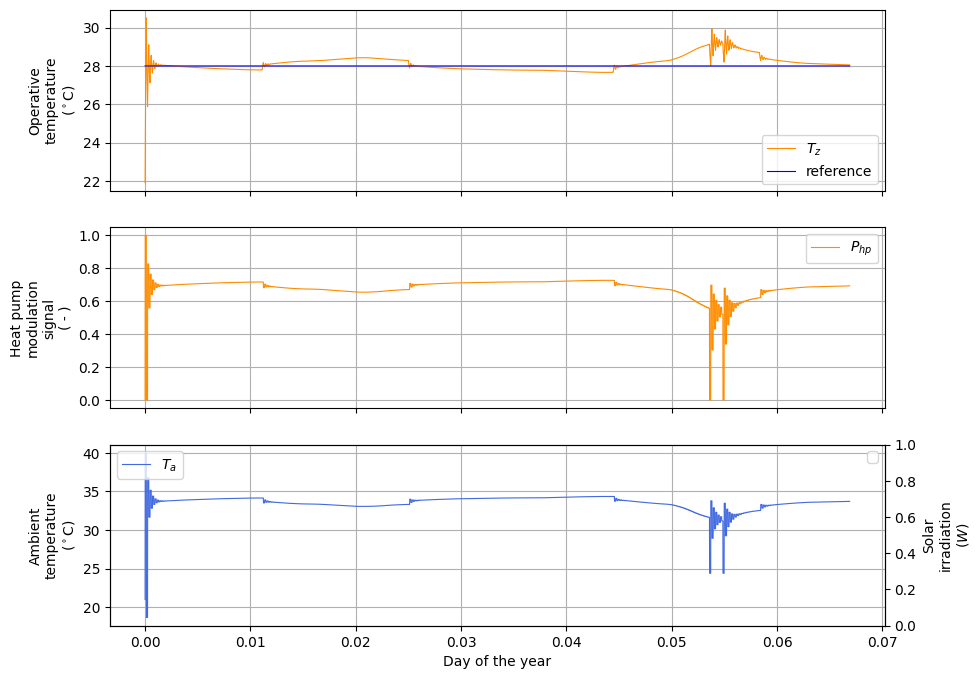

In [25]:
def get_and_plot_results(testid, start_time, final_time):
    df_res = pd.DataFrame()
    points = ['zon_reaTRooAir_y', 'fcu_oveFan_u', 'fcu_oveTSup_u']
    args = {'point_names':points,
            'start_time':start_time, 
            'final_time':final_time}
    res = requests.put('{0}/results/{1}'.format(url, testid), 
                        json=args).json()['payload']
    df_res = pd.DataFrame(data=res)
    print(df_res.head())
    df_res.set_index('time')
    plt.close()
    _, axs = plt.subplots(3, sharex=True, figsize=(10,8))
    x_time = df_res.index/3600./24.
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y']    - 273.15, 'darkorange', linestyle='-', linewidth=0.8, label='$T_z$')
    axs[0].plot(x_time, np.full(len(df_res['zon_reaTRooAir_y']), x_ref), 'blue', linewidth=0.8, label='reference')
    axs[0].set_ylabel('Operative\ntemperature\n($^\circ$C)')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(x_time, df_res['fcu_oveFan_u'], 'darkorange', linestyle='-', linewidth=0.8, label='$P_{hp}$')
    axs[1].set_ylabel('Heat pump\nmodulation\nsignal\n( - )')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, 'royalblue', linestyle='-', linewidth=0.8, label='$T_a$')
    axs[2].set_ylabel('Ambient\ntemperature\n($^\circ$C)')
    axs[2].legend(loc='upper left')
    axs[2].set_xlabel('Day of the year')
    axs[2].grid()
    axt = axs[2].twinx()
    axt.set_ylabel('Solar\nirradiation\n($W$)')
    axt.legend(loc='upper right')
    plt.show()  
    return None
get_and_plot_results(testid=testid, start_time=start_time_days*24*3600 + 0.0*24*3600, final_time=start_time_days*24*3600 + 10*24*3600)